## XGBoost model for Water Pipe Failure Prediction (Joe Tambeana)
- Is one of the most and highly suitable and effective machine learning algorithm for water pipe failure prediction
- It is a supervised ensemple method which is based on gradient boosting decision trees
- It builds strong predictive model by combining many weak learners (decision trees) sequentially

### Import libraries & Environment setup

In [40]:
import pandas as pd
import optuna # For hyperparameter tuning
import numpy as np
import xgboost as xgb
import joblib # For saving the model
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns # For data visualization
import shap # For model interpretability
import optuna  # For hyperparameter tuning
import warnings
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

### Loading dataset & Initial inspection

In [31]:
df = pd.read_csv('/Users/homedesk/Documents/S779/2026/SIT764/capstone/Datasets/kitchener_model_ready.csv')  
print(df.shape)
print(df.columns.tolist())
print(df.info())
print(df.describe())

(16163, 20)
['pressure_zone', 'category', 'pipe_size', 'material', 'lined', 'lined_material', 'acquisition', 'ownership', 'bridge_main', 'criticality', 'rel_cleaning_area', 'rel_cleaning_subarea', 'undersized', 'shallow_main', 'condition_score', 'oversized', 'cleaned', 'shape__length', 'has_break', 'pipe_age']
<class 'pandas.DataFrame'>
RangeIndex: 16163 entries, 0 to 16162
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pressure_zone         16163 non-null  str    
 1   category              16163 non-null  str    
 2   pipe_size             16163 non-null  int64  
 3   material              16163 non-null  str    
 4   lined                 16163 non-null  int64  
 5   lined_material        16163 non-null  str    
 6   acquisition           16163 non-null  str    
 7   ownership             16163 non-null  str    
 8   bridge_main           16163 non-null  int64  
 9   criticality           16

### Data Processing

In [32]:
# Separate features and target
# The target variable is 'has_break', which indicates whether a pipe has experienced a break (1) or not (0)
X = df.drop(columns=['has_break'])
y = df['has_break']

# Identify categorical and numerical columns
cat_cols = ['pressure_zone', 'category', 'material', 'lined_material',
            'acquisition', 'ownership', 'rel_cleaning_subarea']
num_cols = [col for col in X.columns if col not in cat_cols]

# Convert categorical columns to 'category' dtype for XGBoost
for col in cat_cols:
    X[col] = X[col].astype('category')

### Train-Test Split (Stratified)

In [33]:
# Split data into training and testing sets with stratification to maintain class balance
# Original X and y used here to ensure the split is done on the full dataset before any transformations
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)
print(y_train.value_counts(normalize=True))

has_break
0    0.923666
1    0.076334
Name: proportion, dtype: float64


### Handle Class Imbalance

In [34]:
# Calculate scale_pos_weight for XGBoost to handle class imbalance
# This parameter helps XGBoost give more weight to the minority class (breaks) during training
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
print("scale_pos_weight =", scale_pos_weight)  # ~12.1

scale_pos_weight = 12.100303951367781


### Build the XGBoost model

In [35]:
# Define XGBoost model with parameters suitable for imbalanced classification
# The 'enable_categorical=True' allows XGBoost to handle categorical features directly, which is ideal for your dataset.
# The 'tree_method' is set to 'hist' for faster training, especially with larger datasets.
# The 'eval_metric' is set to 'aucpr' (Area Under the Precision-Recall Curve), which is more informative than AUC-ROC for imbalanced datasets.
# The 'scale_pos_weight' parameter is set to the calculated value to help the model focus more on the minority class (failures).

model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',           # best for imbalanced data
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,       # crucial for cat columns
    tree_method='hist',            # faster training method for larger datasets     
    random_state=42,
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

### Hyperparameter Tuning
    
   

In [36]:
# Train the model with early stopping to prevent overfitting and to find the optimal number of trees 
from sklearn.metrics import average_precision_score
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
# Evaluate initial model performance on the test set
def objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 200, 2000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': scale_pos_weight,
    }
    # The 'enable_categorical=True' allows XGBoost to handle categorical features directly, which is ideal for the dataset.
    # The 'tree_method' is set to 'hist' for faster training, especially with larger datasets.
    clf = xgb.XGBClassifier(**param, enable_categorical=True, tree_method='hist', random_state=42)
    clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    # Use predicted probabilities to calculate average precision score, which is more informative for imbalanced datasets
    pred_proba = clf.predict_proba(X_test)[:, 1] 
    return average_precision_score(y_test, pred_proba)
# Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)   # increase for better results
print("Best params:", study.best_params)

[I 2026-04-13 17:24:59,337] A new study created in memory with name: no-name-8797311f-59b9-417d-8a31-98cf7b570258
[I 2026-04-13 17:24:59,651] Trial 0 finished with value: 0.967469466824652 and parameters: {'max_depth': 3, 'learning_rate': 0.1543216432942131, 'n_estimators': 397, 'subsample': 0.9484616889627875, 'colsample_bytree': 0.6750731894577874, 'min_child_weight': 8, 'gamma': 1.9309233761875126}. Best is trial 0 with value: 0.967469466824652.
[I 2026-04-13 17:25:00,429] Trial 1 finished with value: 0.9696515422795949 and parameters: {'max_depth': 4, 'learning_rate': 0.10007067397335997, 'n_estimators': 1011, 'subsample': 0.976251725321287, 'colsample_bytree': 0.7585113782810589, 'min_child_weight': 3, 'gamma': 0.8511262989877522}. Best is trial 1 with value: 0.9696515422795949.
[I 2026-04-13 17:25:00,789] Trial 2 finished with value: 0.9665662878995118 and parameters: {'max_depth': 4, 'learning_rate': 0.1328248206431322, 'n_estimators': 472, 'subsample': 0.9200503665570176, 'cols

Best params: {'max_depth': 4, 'learning_rate': 0.11580570176883113, 'n_estimators': 932, 'subsample': 0.9563401097705959, 'colsample_bytree': 0.7694587364419787, 'min_child_weight': 3, 'gamma': 0.5190791600420319}


### Training the Final Model

In [37]:
# Train final model with best hyperparameters and early stopping to find optimal number of trees based on test set performance 
# Using the best hyperparameters found by Optuna and set early_stopping_rounds to prevent overfitting and to find the optimal number of trees based on the test set performance.
# The 'eval_metric' is set to 'aucpr' to ensure we are optimizing for the right metric given the class imbalance in the dataset.

final_model = xgb.XGBClassifier(
    **study.best_params,
    early_stopping_rounds=50,      #stop if no improvement for 50 rounds
    enable_categorical=True,
    random_state=42,
    eval_metric='aucpr'   # crucial for imbalanced data        
)

# Fit the final model with early stopping to find the optimal number of trees based on the test set performance
final_model.fit(
    X_train, y_train,
    
    eval_set=[(X_test, y_test),(X_train, y_train)], # monitor both train and test to ensure we are not overfitting
    verbose=False
)

print("Best iteration:", final_model.best_iteration)
print("Best score:", final_model.best_score)

Best iteration: 901
Best score: 0.9949526824163343


### Model Evaluation Accuracy and Performance
-  Using the heatmap that helps to quickly identify correct and incorrect prediction

ROC-AUC: 0.9910161048455545
PR-AUC: 0.970271013727918

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2986
           1       0.96      0.95      0.96       247

    accuracy                           0.99      3233
   macro avg       0.98      0.97      0.98      3233
weighted avg       0.99      0.99      0.99      3233



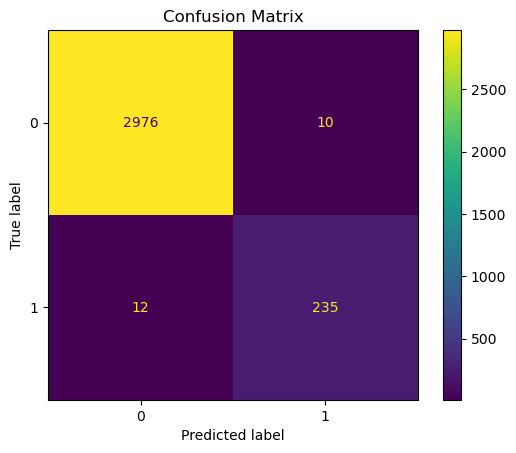

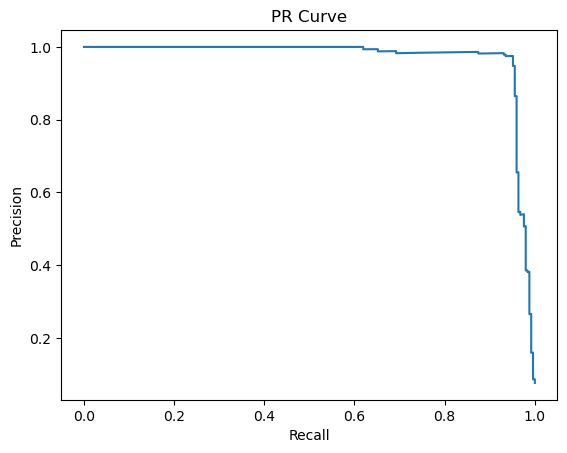

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve

# Evaluate final model performance on the test set
y_pred = final_model.predict(X_test)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]

# Print evaluation metrics
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print("PR-AUC:", average_precision_score(y_test, y_pred_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()

# Precision-Recall curve  
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve')
plt.show()

### Ploting Feature Importance
- Visualizing the importance of each feature in the XGBoost model to understand which variables contribute most to predictions
- It is crucial for understanding pipe failure risks and for making informed maintenance decisions.

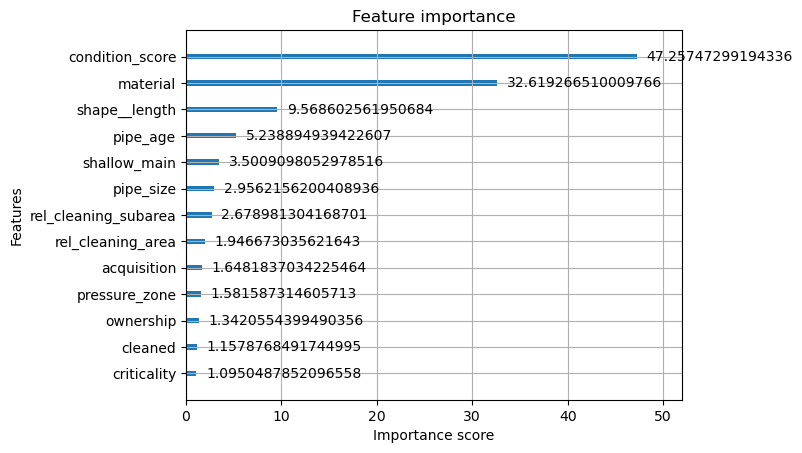

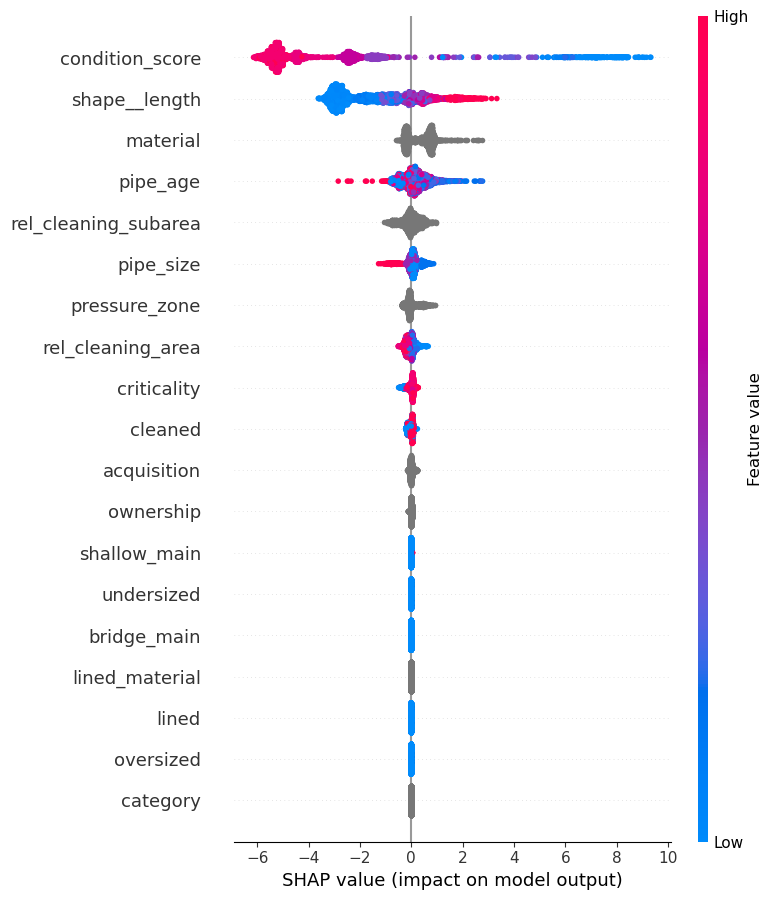

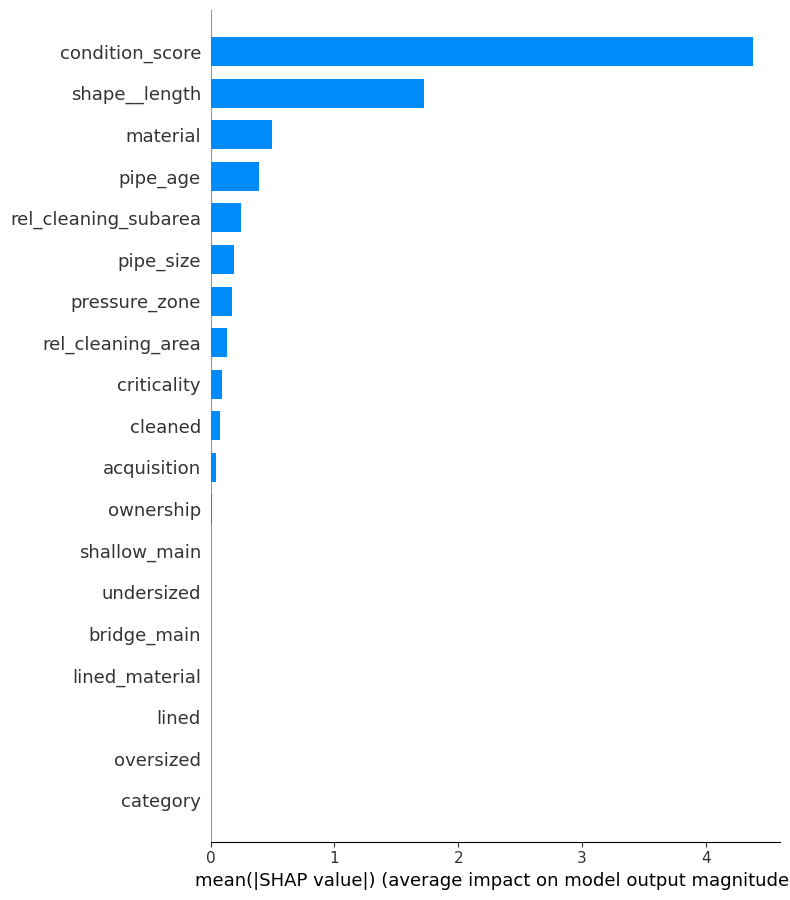

In [39]:
# Feature importance - using 'gain' to see which features contribute most to improving the model's performance.
xgb.plot_importance(final_model, importance_type='gain', max_num_features=15)
plt.show()

# SHAP - highly recommended for pipe failure interpretability
explainer = shap.TreeExplainer(final_model)
# SHAP values provide insights into how each feature contributes to the model's predictions. 
# This is crucial for understanding pipe failure risks and for making informed maintenance decisions.
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

### Saving the Model

In [44]:
# Save the final model to disk for future use in deployment or further analysis
joblib.dump(final_model, 'xgboost_water_pipe_failure_model.pkl')

['xgboost_water_pipe_failure_model.pkl']